In [1]:
# Cell 1: Install dependencies
!pip install pandas numpy scikit-learn matplotlib seaborn joblib torch

In [2]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_recall_fscore_support

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, classification_report)
from sklearn.pipeline import make_pipeline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 3: Load Data (automatic — loads whatever *_data.csv files are present)
# Upload your CSV files via the Colab file browser, then run this cell.
# Works with ANY number of classes: 2, 3, 5, 9 — it trains on whatever you uploaded.
# Example: with only air_data.csv and vinegar_data.csv present it trains a 2-class model.

import glob

csv_files = sorted(glob.glob("*_data.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No '*_data.csv' files found. Upload your data files "
        "(e.g. air_data.csv, vinegar_data.csv) via the Colab file browser first."
    )

print(f"Found {len(csv_files)} data file(s):")
frames = []
for path in csv_files:
    d = pd.read_csv(path)
    frames.append(d)
    lbl = d["label"].iloc[0] if "label" in d.columns and len(d) else "?"
    print(f"  {path:<28} -> {len(d):>6} rows  (label: {lbl})")

df = pd.concat(frames, ignore_index=True)

before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if 'sensor' in c]).reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows")

print(f"\nTotal samples: {len(df)}")
print(f"Classes found ({df['label'].nunique()}): {sorted(df['label'].unique())}")
print(f"\nClass distribution:")
print(df["label"].value_counts())

if df["label"].nunique() < 2:
    raise ValueError(
        f"Only {df['label'].nunique()} class present. Need at least 2 classes to train a classifier. "
        "Upload at least two *_data.csv files."
    )


Found 10 data file(s):
  air_data.csv                 ->    858 rows  (label: air)
  chillipowder_data.csv        ->    854 rows  (label: chillipowder)
  cinnamon_data.csv            ->    858 rows  (label: cinnamon)
  coffee_data.csv              ->    854 rows  (label: coffee)
  corrianderpowder_data.csv    ->    858 rows  (label: corrianderpowder)
  masalapowder_data.csv        ->    858 rows  (label: masalapowder)
  pepperpowder_data.csv        ->    858 rows  (label: pepperpowder)
  vinegar_data.csv             ->    858 rows  (label: vinegar)
  whiskey_data.csv             ->    858 rows  (label: whiskey)
  wine_data.csv                ->    858 rows  (label: wine)
Removed 0 duplicate rows

Total samples: 8572
Classes found (10): ['air', 'chillipowder', 'cinnamon', 'coffee', 'corrianderpowder', 'masalapowder', 'pepperpowder', 'vinegar', 'whiskey', 'wine']

Class distribution:
label
air                 858
cinnamon            858
whiskey             858
corrianderpowder    858
mas

In [4]:
# Cell 4: Feature Engineering
# Gas resistance (8) + gas index (8) + log-transformed gas resistance (8) = 24 features total
# Gas index is included because each sensor is at a different heater step simultaneously
# (a single uniform HP-354 profile; the 8 sensors are nonetheless at
#  different heater steps at any instant because they run asynchronously)
# Without gas index the model cannot distinguish readings from different temperature steps

gas_cols   = [col for col in df.columns if 'sensor' in col and 'gas' in col and 'index' not in col]
index_cols = [col for col in df.columns if 'gas_index' in col]

print(f"Gas resistance columns ({len(gas_cols)}): {gas_cols}")
print(f"Gas index columns ({len(index_cols)}): {index_cols}")

X = df[gas_cols + index_cols].ffill().bfill()
X = X.dropna()

# Log transform only gas resistance — not gas index (already 0-9 scale)
for col in gas_cols:
    X[f"{col}_log"] = np.log1p(X[col])

feature_cols = list(X.columns)
y = df["label"][X.index]

print(f"Total features ({len(feature_cols)}): {feature_cols}")
print(f"Shape: {X.shape}")
print(f"Class distribution:")
print(y.value_counts())


Gas resistance columns (8): ['sensor_0_gas', 'sensor_1_gas', 'sensor_2_gas', 'sensor_3_gas', 'sensor_4_gas', 'sensor_5_gas', 'sensor_6_gas', 'sensor_7_gas']
Gas index columns (8): ['sensor_0_gas_index', 'sensor_1_gas_index', 'sensor_2_gas_index', 'sensor_3_gas_index', 'sensor_4_gas_index', 'sensor_5_gas_index', 'sensor_6_gas_index', 'sensor_7_gas_index']
Total features (24): ['sensor_0_gas', 'sensor_1_gas', 'sensor_2_gas', 'sensor_3_gas', 'sensor_4_gas', 'sensor_5_gas', 'sensor_6_gas', 'sensor_7_gas', 'sensor_0_gas_index', 'sensor_1_gas_index', 'sensor_2_gas_index', 'sensor_3_gas_index', 'sensor_4_gas_index', 'sensor_5_gas_index', 'sensor_6_gas_index', 'sensor_7_gas_index', 'sensor_0_gas_log', 'sensor_1_gas_log', 'sensor_2_gas_log', 'sensor_3_gas_log', 'sensor_4_gas_log', 'sensor_5_gas_log', 'sensor_6_gas_log', 'sensor_7_gas_log']
Shape: (8572, 24)
Class distribution:
label
air                 858
cinnamon            858
whiskey             858
corrianderpowder    858
masalapowder     

In [5]:
# Blocked temporal split: the first 80% of each class recording trains,
# the final 20% tests. Consecutive readings from a temperature-modulated
# sensor are correlated, so a random split would place near-identical
# neighbouring rows on both sides of the partition and measure
# memorisation rather than generalisation (Bergmeir & Benitez, 2012).
y_arr = y.to_numpy()
train_idx, test_idx = [], []
for lbl in sorted(y.unique()):
    pos = np.where(y_arr == lbl)[0]      # already in recording order
    cut = int(len(pos) * 0.8)
    train_idx.extend(pos[:cut])
    test_idx.extend(pos[cut:])
train_idx, test_idx = np.array(train_idx), np.array(test_idx)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Clean any NaN/inf after scaling (needed for MLP)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)

labels = sorted(y.unique())
print(f"Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
print(f"Classes: {labels}")
print(f"Features: {len(feature_cols)} (8 gas resistance + 8 gas index + 8 log-transformed)")


Train: (6854, 24)  Test: (1718, 24)
Classes: ['air', 'chillipowder', 'cinnamon', 'coffee', 'corrianderpowder', 'masalapowder', 'pepperpowder', 'vinegar', 'whiskey', 'wine']
Features: 24 (8 gas resistance + 8 gas index + 8 log-transformed)


In [6]:
# Blocked 5-fold CV: each class recording is cut into five contiguous
# folds, each serving in turn as validation. Replaces cross_val_score,
# which shuffles and therefore leaks across correlated neighbours.
def blocked_cv(make_model, X, y, n_splits=5, encode=False):
    Xv = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    yv = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)
    classes = sorted(pd.unique(yv))
    scores = []
    for k in range(n_splits):
        tr, te = [], []
        for lbl in classes:
            pos = np.where(yv == lbl)[0]
            n = len(pos)
            lo, hi = int(n * k / n_splits), int(n * (k + 1) / n_splits)
            te.extend(pos[lo:hi])
            tr.extend(np.concatenate([pos[:lo], pos[hi:]]))
        tr, te = np.array(tr), np.array(te)
        sc_k = MinMaxScaler()
        A = np.nan_to_num(sc_k.fit_transform(Xv[tr]))
        B = np.nan_to_num(sc_k.transform(Xv[te]))
        a, b = yv[tr], yv[te]
        if encode:
            le_k = LabelEncoder().fit(yv)
            a, b = le_k.transform(a), le_k.transform(b)
        m = make_model()
        m.fit(A, a)
        scores.append(accuracy_score(b, m.predict(B)))
    return np.array(scores)

KNN Accuracy:    0.951
KNN CV:          0.955 +/- 0.035
KNN Latency:     1.140 ms
                  precision    recall  f1-score   support

             air       0.97      1.00      0.98       172
    chillipowder       0.95      0.92      0.93       171
        cinnamon       0.85      0.95      0.90       172
          coffee       1.00      0.75      0.86       171
corrianderpowder       0.97      0.98      0.97       172
    masalapowder       0.99      0.98      0.99       172
    pepperpowder       0.97      0.99      0.98       172
         vinegar       0.89      1.00      0.94       172
         whiskey       1.00      0.95      0.97       172
            wine       0.97      0.99      0.98       172

        accuracy                           0.95      1718
       macro avg       0.95      0.95      0.95      1718
    weighted avg       0.95      0.95      0.95      1718



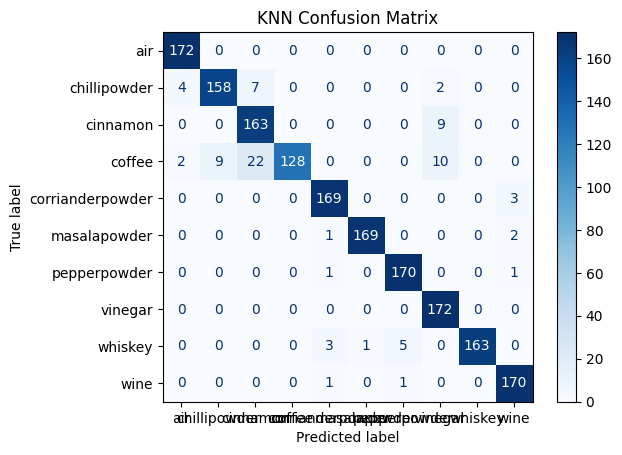

In [7]:
# Cell 6: KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")
knn.fit(X_train_sc, y_train)

knn_pred = knn.predict(X_test_sc)
knn_acc  = accuracy_score(y_test, knn_pred)
knn_prf = precision_recall_fscore_support(y_test, knn_pred, average="macro", zero_division=0)

start = time.perf_counter()
for _ in range(1000): knn.predict(X_test_sc[:1])
knn_latency_ms = (time.perf_counter() - start) * 1000 / 1000

knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean"))
knn_cv = blocked_cv(lambda: KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean"), X, y)

print(f"KNN Accuracy:    {knn_acc:.3f}")
print(f"KNN CV:          {knn_cv.mean():.3f} +/- {knn_cv.std():.3f}")
print(f"KNN Latency:     {knn_latency_ms:.3f} ms")
print(classification_report(y_test, knn_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, knn_pred, labels=labels), display_labels=labels).plot(cmap="Blues")
plt.title("KNN Confusion Matrix"); plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight"); plt.show()

RF Accuracy:     0.910
RF CV:           0.938 +/- 0.060
RF Latency:      27.029 ms
                  precision    recall  f1-score   support

             air       0.88      1.00      0.93       172
    chillipowder       0.97      0.92      0.94       171
        cinnamon       0.78      0.84      0.81       172
          coffee       0.71      0.57      0.63       171
corrianderpowder       1.00      1.00      1.00       172
    masalapowder       1.00      1.00      1.00       172
    pepperpowder       1.00      1.00      1.00       172
         vinegar       0.75      0.76      0.76       172
         whiskey       1.00      1.00      1.00       172
            wine       1.00      1.00      1.00       172

        accuracy                           0.91      1718
       macro avg       0.91      0.91      0.91      1718
    weighted avg       0.91      0.91      0.91      1718



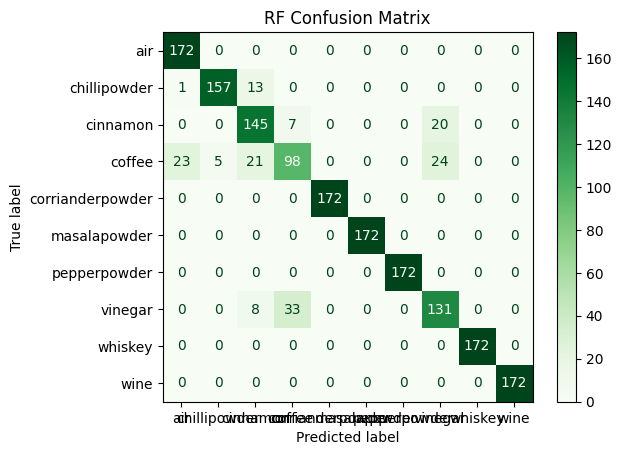

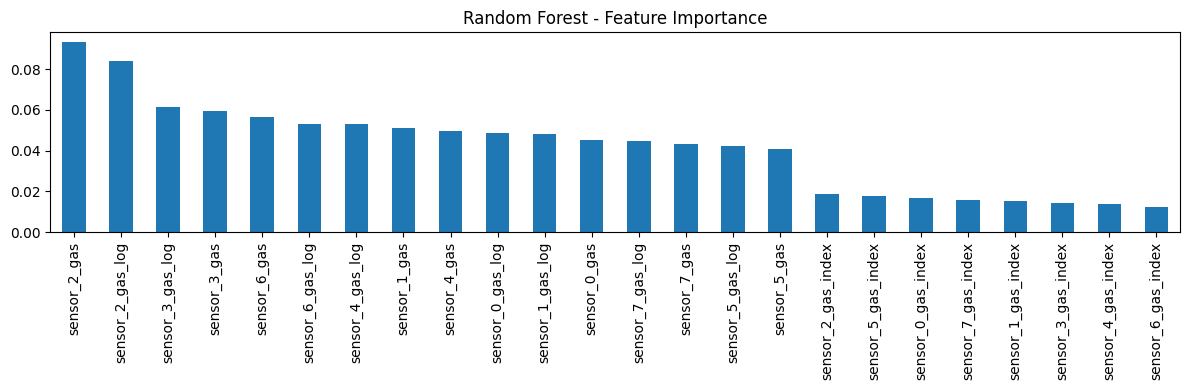

In [8]:
# Cell 7: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42)
rf.fit(X_train_sc, y_train)

rf_pred = rf.predict(X_test_sc)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prf = precision_recall_fscore_support(y_test, rf_pred, average="macro", zero_division=0)

start = time.perf_counter()
for _ in range(1000): rf.predict(X_test_sc[:1])
rf_latency_ms = (time.perf_counter() - start) * 1000 / 1000

rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42))
rf_cv = blocked_cv(lambda: RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42), X, y)

print(f"RF Accuracy:     {rf_acc:.3f}")
print(f"RF CV:           {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
print(f"RF Latency:      {rf_latency_ms:.3f} ms")
print(classification_report(y_test, rf_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred, labels=labels), display_labels=labels).plot(cmap="Greens")
plt.title("RF Confusion Matrix"); plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight"); plt.show()

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(12, 4))
importances.plot(kind="bar")
plt.title("Random Forest - Feature Importance"); plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()

SVM Accuracy:    0.936
SVM CV:          0.933 +/- 0.033
SVM Latency:     0.424 ms
                  precision    recall  f1-score   support

             air       0.92      1.00      0.96       172
    chillipowder       0.88      0.65      0.75       171
        cinnamon       0.74      0.99      0.85       172
          coffee       1.00      0.75      0.86       171
corrianderpowder       1.00      1.00      1.00       172
    masalapowder       0.99      1.00      1.00       172
    pepperpowder       1.00      0.99      1.00       172
         vinegar       0.92      0.99      0.96       172
         whiskey       0.99      0.99      0.99       172
            wine       0.99      0.99      0.99       172

        accuracy                           0.94      1718
       macro avg       0.94      0.94      0.93      1718
    weighted avg       0.94      0.94      0.93      1718



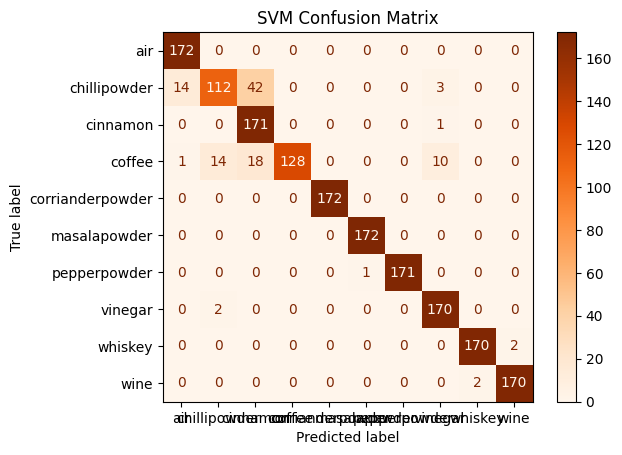

In [9]:
# Cell 8: SVM Classifier
svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

svm_pred = svm.predict(X_test_sc)
svm_acc  = accuracy_score(y_test, svm_pred)
svm_prf = precision_recall_fscore_support(y_test, svm_pred, average="macro", zero_division=0)

start = time.perf_counter()
for _ in range(1000): svm.predict(X_test_sc[:1])
svm_latency_ms = (time.perf_counter() - start) * 1000 / 1000

svm_pipeline = make_pipeline(MinMaxScaler(), SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42))
svm_cv = blocked_cv(lambda: SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42), X, y)

print(f"SVM Accuracy:    {svm_acc:.3f}")
print(f"SVM CV:          {svm_cv.mean():.3f} +/- {svm_cv.std():.3f}")
print(f"SVM Latency:     {svm_latency_ms:.3f} ms")
print(classification_report(y_test, svm_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred, labels=labels), display_labels=labels).plot(cmap="Oranges")
plt.title("SVM Confusion Matrix"); plt.savefig("confusion_matrix_svm.png", dpi=150, bbox_inches="tight"); plt.show()

MLP Accuracy:    0.914
MLP CV:          0.927 +/- 0.035
MLP Latency:     0.227 ms
                  precision    recall  f1-score   support

             air       0.99      0.90      0.94       172
    chillipowder       0.91      0.67      0.77       171
        cinnamon       0.65      0.90      0.76       172
          coffee       0.95      0.74      0.83       171
corrianderpowder       1.00      0.99      0.99       172
    masalapowder       0.98      1.00      0.99       172
    pepperpowder       1.00      0.98      0.99       172
         vinegar       0.80      0.95      0.87       172
         whiskey       1.00      0.99      1.00       172
            wine       0.99      1.00      0.99       172

        accuracy                           0.91      1718
       macro avg       0.93      0.91      0.91      1718
    weighted avg       0.93      0.91      0.91      1718



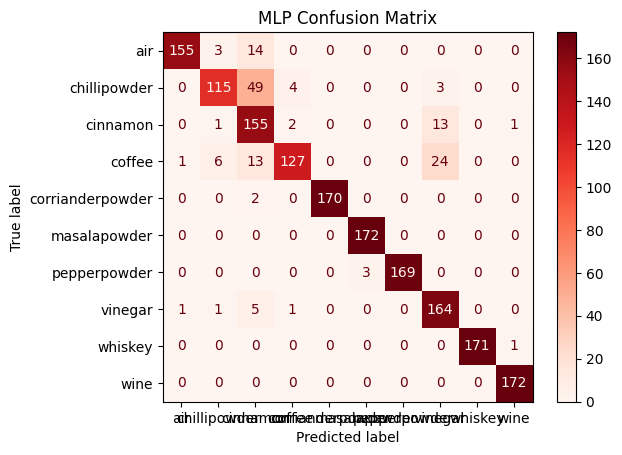

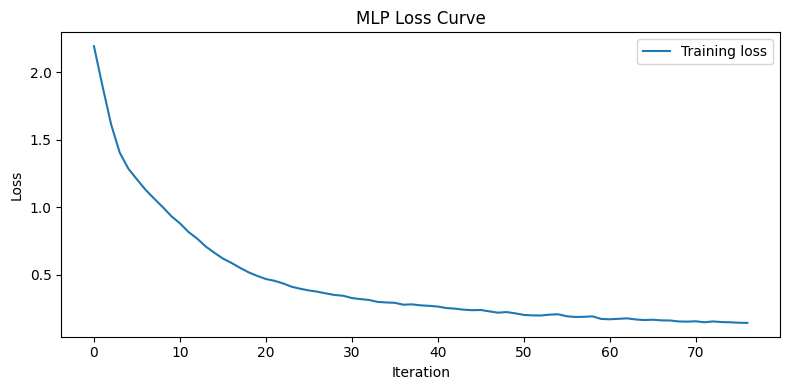

In [10]:
# Cell 9: MLP Neural Network
# Architecture: 24 inputs -> 128 -> 64 -> 32 -> num_classes (input size inferred automatically)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
y_enc       = le.transform(y)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_sc, y_train_enc)

mlp_pred_enc  = mlp.predict(X_test_sc)
mlp_pred      = le.inverse_transform(mlp_pred_enc)
mlp_acc       = accuracy_score(y_test, mlp_pred)
mlp_prf = precision_recall_fscore_support(y_test, mlp_pred, average="macro", zero_division=0)

start = time.perf_counter()
for _ in range(1000): mlp.predict(X_test_sc[:1])
mlp_latency_ms = (time.perf_counter() - start) * 1000 / 1000

mlp_pipeline = make_pipeline(MinMaxScaler(), MLPClassifier(hidden_layer_sizes=(128, 64, 32),
    activation="relu", solver="adam", max_iter=500, early_stopping=True,
    validation_fraction=0.1, random_state=42))
mlp_cv = blocked_cv(lambda: MLPClassifier(hidden_layer_sizes=(128,64,32), activation="relu", solver="adam", max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=42), X, y, encode=True)

print(f"MLP Accuracy:    {mlp_acc:.3f}")
print(f"MLP CV:          {mlp_cv.mean():.3f} +/- {mlp_cv.std():.3f}")
print(f"MLP Latency:     {mlp_latency_ms:.3f} ms")
print(classification_report(y_test, mlp_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, mlp_pred, labels=labels), display_labels=labels).plot(cmap="Reds")
plt.title("MLP Confusion Matrix"); plt.savefig("confusion_matrix_mlp.png", dpi=150, bbox_inches="tight"); plt.show()

plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="Training loss")
plt.title("MLP Loss Curve"); plt.xlabel("Iteration"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("mlp_loss_curve.png", dpi=150, bbox_inches="tight"); plt.show()

Train: (5406, 10, 24)   Val: (1358, 10, 24)   Test: (1628, 10, 24)
Epoch  10/50  Loss: 0.4401  Val Acc: 0.865
Epoch  20/50  Loss: 0.2077  Val Acc: 0.903
Epoch  30/50  Loss: 0.1469  Val Acc: 0.943
Epoch  40/50  Loss: 0.0744  Val Acc: 0.962
Epoch  50/50  Loss: 0.0589  Val Acc: 0.962

Best validation accuracy: 0.985

LSTM Accuracy:   0.925
LSTM Latency:    0.435 ms per sequence
                  precision    recall  f1-score   support

             air       0.90      1.00      0.95       163
    chillipowder       0.89      0.83      0.86       162
        cinnamon       0.84      0.83      0.83       163
          coffee       0.91      0.66      0.76       162
corrianderpowder       0.99      1.00      1.00       163
    masalapowder       1.00      1.00      1.00       163
    pepperpowder       0.97      1.00      0.98       163
         vinegar       0.78      0.96      0.86       163
         whiskey       1.00      0.97      0.98       163
            wine       1.00      0.99    

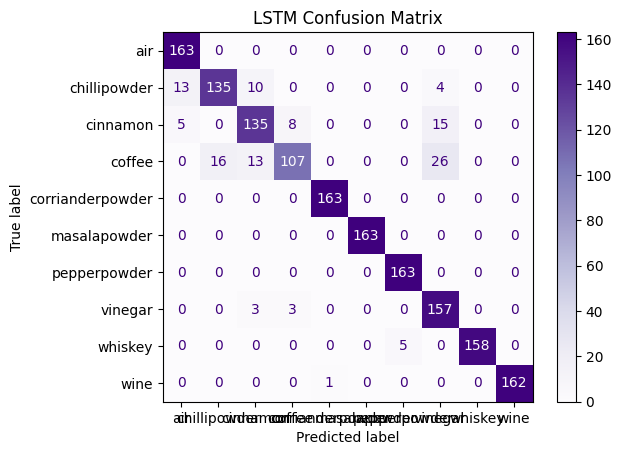

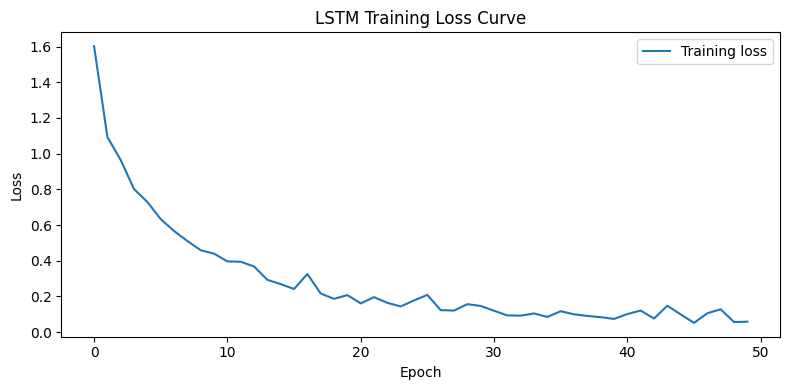

In [11]:
# Cell 10: LSTM Neural Network
# Unlike other models which classify one snapshot at a time,
# LSTM takes a sequence of consecutive readings and learns how
# gas resistance changes over time as the smell diffuses into the sensor.

SEQ_LEN    = 10   # 10 consecutive readings
N_FEATURES = len(feature_cols)  # 24 features per timestep (8 gas + 8 gas_index + 8 log)
N_CLASSES  = len(labels)
EPOCHS     = 50
BATCH_SIZE = 32

# ── Label encoding (reuse le from MLP cell) ──────────────────────────────────
# le, y_enc already defined in Cell 9

# ── Build sequences from the scaled data ─────────────────────────────────────
# Group consecutive rows from the same class into sliding windows
def build_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len + 1):
        # Only create a sequence if all steps belong to the same class
        window_labels = y_arr[i:i + seq_len]
        if len(set(window_labels)) == 1:
            Xs.append(X_arr[i:i + seq_len])
            ys.append(window_labels[-1])
    return np.array(Xs), np.array(ys)

# Build sequences SEPARATELY within each partition, using the same blocked
# index split as the snapshot models. Sliding windows overlap by nine
# readings out of ten, so building them before splitting would place
# near-identical windows in both train and test.
X_all_sc = scaler.transform(X)
X_all_sc = np.nan_to_num(X_all_sc, nan=0.0, posinf=0.0, neginf=0.0)
y_all_enc = le.transform(y)

def seqs_from(idx_list):
    Xs, ys = [], []
    for pos in idx_list:
        for i in range(len(pos) - SEQ_LEN + 1):
            w = pos[i:i + SEQ_LEN]
            if not np.all(np.diff(w) == 1):        # contiguous only
                continue
            if len(set(y_all_enc[w])) != 1:        # single label only
                continue
            Xs.append(X_all_sc[w])
            ys.append(y_all_enc[w[-1]])
    return np.array(Xs), np.array(ys)

tr_blocks, te_blocks = [], []
for lbl in sorted(y.unique()):
    pos = np.where(y.to_numpy() == lbl)[0]
    cut = int(len(pos) * 0.8)
    tr_blocks.append(pos[:cut])
    te_blocks.append(pos[cut:])

X_seq_tr_full, y_seq_tr_full = seqs_from(tr_blocks)
X_seq_te, y_seq_te = seqs_from(te_blocks)

# Hold out the last 20% of each class's TRAINING sequences for model
# selection, so the test set is never seen until the final evaluation.
# Blocked rather than random, for the same reason as the main split.
tr_sel, val_sel = [], []
for cls in np.unique(y_seq_tr_full):
    pos = np.where(y_seq_tr_full == cls)[0]
    cut = int(len(pos) * 0.8)
    tr_sel.extend(pos[:cut])
    val_sel.extend(pos[cut:])
tr_sel, val_sel = np.array(tr_sel), np.array(val_sel)

X_seq_tr, y_seq_tr = X_seq_tr_full[tr_sel], y_seq_tr_full[tr_sel]
X_seq_val, y_seq_val = X_seq_tr_full[val_sel], y_seq_tr_full[val_sel]

print(f"Train: {X_seq_tr.shape}   Val: {X_seq_val.shape}   Test: {X_seq_te.shape}")

# Convert to PyTorch tensors
X_tr_t = torch.FloatTensor(X_seq_tr).to(device)
y_tr_t = torch.LongTensor(y_seq_tr).to(device)
X_val_t = torch.FloatTensor(X_seq_val).to(device)
y_val_t = torch.LongTensor(y_seq_val).to(device)
X_te_t = torch.FloatTensor(X_seq_te).to(device)
y_te_t = torch.LongTensor(y_seq_te).to(device)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)

# ── LSTM model definition ─────────────────────────────────────────────────────
class ENoseLSTM(nn.Module):
    def __init__(self, n_features, hidden_size, n_layers, n_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])  # take last timestep
        return self.fc(out)

lstm_model = ENoseLSTM(
    n_features=N_FEATURES,
    hidden_size=64,
    n_layers=2,
    n_classes=N_CLASSES,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses = []
best_val_acc = 0
best_state   = None

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validation accuracy — computed on the held-out validation split,
    # NOT the test set, so model selection cannot leak test information.
    lstm_model.eval()
    with torch.no_grad():
        val_preds = lstm_model(X_val_t).argmax(dim=1)
        val_acc   = (val_preds == y_val_t).float().mean().item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in lstm_model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.4f}  Val Acc: {val_acc:.3f}")

# Load best weights
if best_state is not None:
    lstm_model.load_state_dict(best_state)
else:
    print("Warning: No best model state found. Using the last trained state.")
print(f"\nBest validation accuracy: {best_val_acc:.3f}")

# ── Evaluation ───────────────────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    lstm_logits = lstm_model(X_te_t)
    lstm_pred_enc = lstm_logits.argmax(dim=1).cpu().numpy()

lstm_pred = le.inverse_transform(lstm_pred_enc)
lstm_true = le.inverse_transform(y_seq_te)
lstm_acc  = accuracy_score(lstm_true, lstm_pred)
lstm_prf = precision_recall_fscore_support(lstm_true, lstm_pred, average="macro", zero_division=0)

# Latency benchmark (single sequence)
single_seq = torch.FloatTensor(X_seq_te[:1]).to(device)
start = time.perf_counter()
with torch.no_grad():
    for _ in range(1000): lstm_model(single_seq)
lstm_latency_ms = (time.perf_counter() - start) * 1000 / 1000

print(f"\nLSTM Accuracy:   {lstm_acc:.3f}")
print(f"LSTM Latency:    {lstm_latency_ms:.3f} ms per sequence")
print(classification_report(lstm_true, lstm_pred, target_names=labels))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(lstm_true, lstm_pred, labels=labels),
    display_labels=labels
).plot(cmap="Purples")
plt.title("LSTM Confusion Matrix")
plt.savefig("confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training loss")
plt.title("LSTM Training Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout()
plt.savefig("lstm_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Store for comparison
# Best accuracy on the held-out validation split used for epoch selection.
# Not a k-fold CV score; reported separately in the comparison table.
lstm_val_acc = best_val_acc
lstm_cv_placeholder = np.nan   # LSTM is not cross-validated

Ensemble Accuracy: 0.964
Ensemble CV:       0.963 +/- 0.033
Ensemble Latency:  13.845 ms
                  precision    recall  f1-score   support

             air       0.97      1.00      0.99       172
    chillipowder       0.94      0.89      0.92       171
        cinnamon       0.84      0.99      0.91       172
          coffee       1.00      0.76      0.86       171
corrianderpowder       1.00      1.00      1.00       172
    masalapowder       1.00      1.00      1.00       172
    pepperpowder       1.00      1.00      1.00       172
         vinegar       0.93      1.00      0.96       172
         whiskey       1.00      0.99      1.00       172
            wine       0.99      1.00      1.00       172

        accuracy                           0.96      1718
       macro avg       0.97      0.96      0.96      1718
    weighted avg       0.97      0.96      0.96      1718



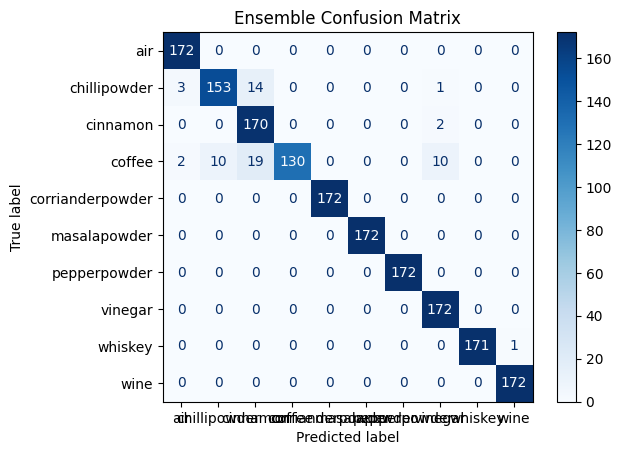

In [12]:
# Cell 11: Voting Ensemble (KNN + RF + SVM)
# Note: LSTM uses sequential data so cannot be included in the sklearn VotingClassifier
# It is compared separately in the results table

ensemble = VotingClassifier(
    estimators=[("knn", knn), ("rf", rf), ("svm", svm)],
    voting="soft"
)
ensemble.fit(X_train_sc, y_train)

ens_pred = ensemble.predict(X_test_sc)
ens_acc  = accuracy_score(y_test, ens_pred)
ens_prf = precision_recall_fscore_support(y_test, ens_pred, average="macro", zero_division=0)

start = time.perf_counter()
for _ in range(1000): ensemble.predict(X_test_sc[:1])
ens_latency_ms = (time.perf_counter() - start) * 1000 / 1000

ens_pipeline = make_pipeline(
    MinMaxScaler(),
    VotingClassifier(
        estimators=[
            ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")),
            ("rf",  RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42)),
            ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42))
        ], voting="soft"
    )
)
ens_cv = blocked_cv(lambda: VotingClassifier(estimators=[("knn", KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")), ("rf", RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42)), ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42))], voting="soft"), X, y)

print(f"Ensemble Accuracy: {ens_acc:.3f}")
print(f"Ensemble CV:       {ens_cv.mean():.3f} +/- {ens_cv.std():.3f}")
print(f"Ensemble Latency:  {ens_latency_ms:.3f} ms")
print(classification_report(y_test, ens_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, ens_pred, labels=labels), display_labels=labels).plot(cmap="Blues")
plt.title("Ensemble Confusion Matrix"); plt.savefig("confusion_matrix_ensemble.png", dpi=150, bbox_inches="tight"); plt.show()

        Model  Accuracy  Precision  Recall     F1  CV Mean  CV Std  Latency(ms)       Type
          KNN    0.9511     0.9544  0.9510 0.9502   0.9548  0.0352       1.1395   Snapshot
Random Forest    0.9098     0.9081  0.9096 0.9075   0.9376  0.0596      27.0289   Snapshot
          SVM    0.9360     0.9430  0.9357 0.9338   0.9332  0.0335       0.4238   Snapshot
          MLP    0.9139     0.9274  0.9136 0.9146   0.9266  0.0349       0.2267   Snapshot
         LSTM    0.9251     0.9281  0.9248 0.9231      NaN     NaN       0.4351 Sequential
     Ensemble    0.9639     0.9672  0.9638 0.9630   0.9633  0.0329      13.8445   Snapshot


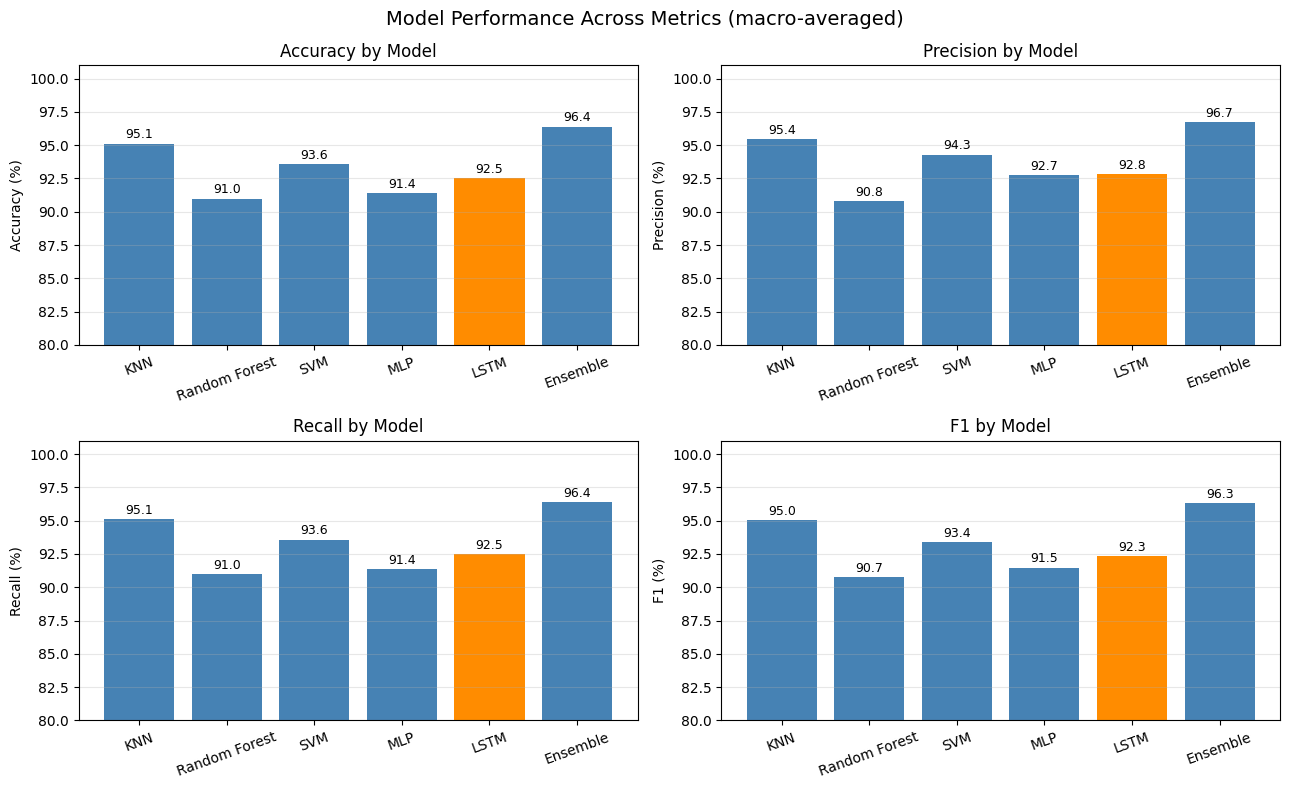

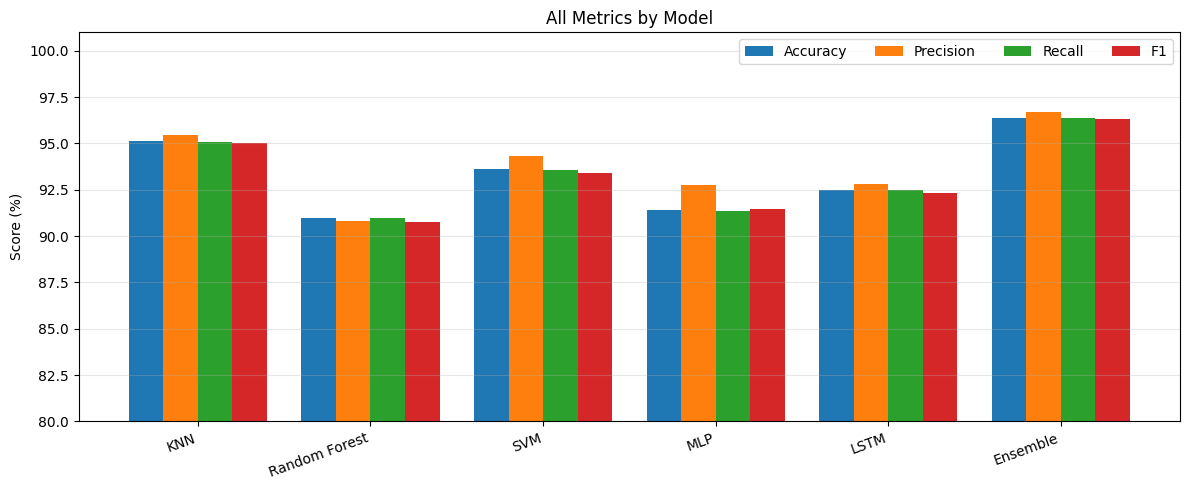

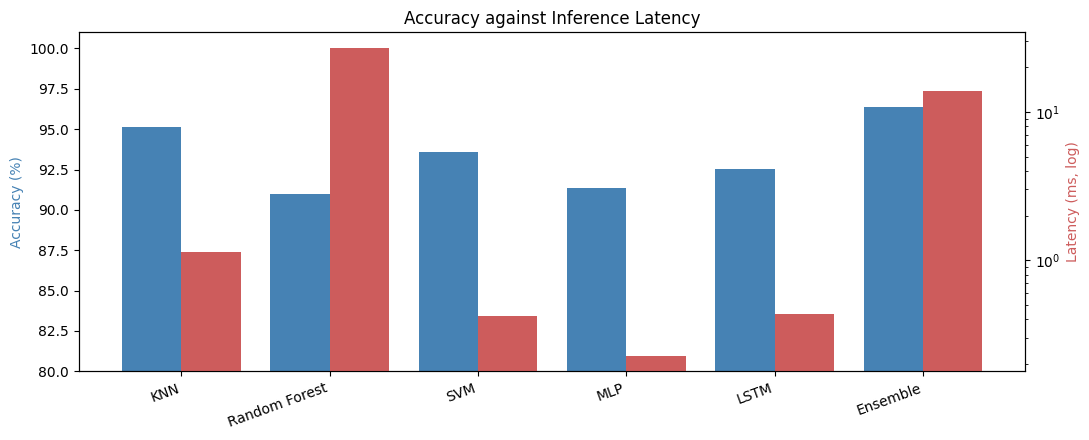

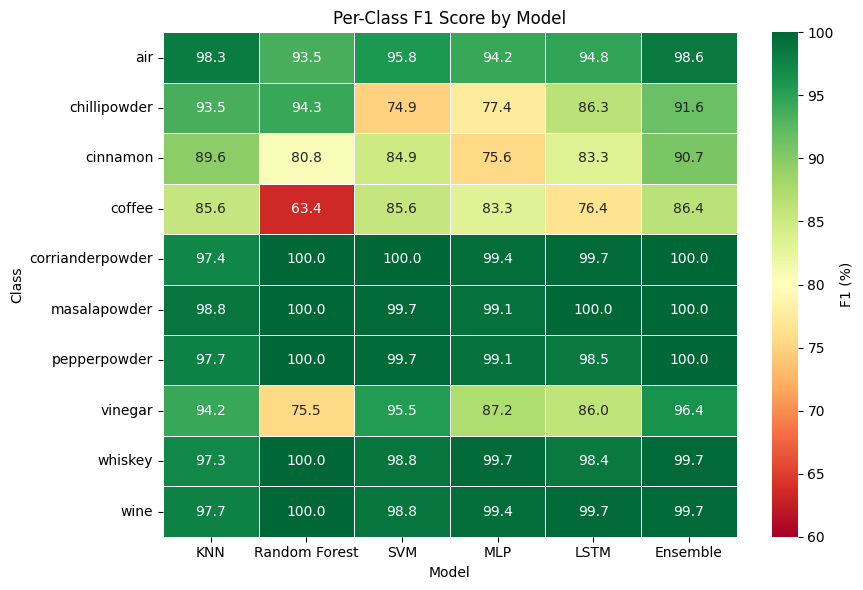


Weakest classes (mean F1 across models):
coffee          80.1
cinnamon        84.1
chillipowder    86.3
vinegar         89.1

Best overall: Ensemble


In [13]:
# Cell 12: Model Comparison — accuracy, precision, recall, F1 and latency
results = pd.DataFrame({
    "Model":       ["KNN", "Random Forest", "SVM", "MLP", "LSTM", "Ensemble"],
    "Accuracy":    [knn_acc, rf_acc, svm_acc, mlp_acc, lstm_acc, ens_acc],
    "Precision":   [knn_prf[0], rf_prf[0], svm_prf[0], mlp_prf[0], lstm_prf[0], ens_prf[0]],
    "Recall":      [knn_prf[1], rf_prf[1], svm_prf[1], mlp_prf[1], lstm_prf[1], ens_prf[1]],
    "F1":          [knn_prf[2], rf_prf[2], svm_prf[2], mlp_prf[2], lstm_prf[2], ens_prf[2]],
    "CV Mean":     [knn_cv.mean(), rf_cv.mean(), svm_cv.mean(), mlp_cv.mean(), np.nan, ens_cv.mean()],
    "CV Std":      [knn_cv.std(),  rf_cv.std(),  svm_cv.std(),  mlp_cv.std(),  np.nan, ens_cv.std()],
    "Latency(ms)": [knn_latency_ms, rf_latency_ms, svm_latency_ms,
                    mlp_latency_ms, lstm_latency_ms, ens_latency_ms],
    "Type":        ["Snapshot"]*4 + ["Sequential", "Snapshot"],
})
print(results.round(4).to_string(index=False))

metrics = ["Accuracy", "Precision", "Recall", "F1"]
models  = results["Model"].tolist()

# ── Figure 1: one panel per metric ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, met in zip(axes.ravel(), metrics):
    vals = results[met].values * 100
    cols = ["darkorange" if t == "Sequential" else "steelblue" for t in results["Type"]]
    bars = ax.bar(models, vals, color=cols)
    ax.set_title(f"{met} by Model", fontsize=12)
    ax.set_ylabel(f"{met} (%)")
    ax.set_ylim(min(80, vals.min() - 5), 101)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.1f}",
                ha="center", fontsize=9)
fig.suptitle("Model Performance Across Metrics (macro-averaged)", fontsize=14)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: grouped bars, all metrics side by side ────────────────────────
x = np.arange(len(models)); w = 0.2
plt.figure(figsize=(12, 5))
for i, met in enumerate(metrics):
    plt.bar(x + (i - 1.5)*w, results[met]*100, w, label=met)
plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Score (%)"); plt.ylim(80, 101)
plt.title("All Metrics by Model")
plt.legend(ncol=4); plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metric_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: accuracy against latency ──────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(x - 0.2, results["Accuracy"]*100, 0.4, color="steelblue", label="Accuracy")
ax1.set_ylabel("Accuracy (%)", color="steelblue"); ax1.set_ylim(80, 101)
ax2 = ax1.twinx()
ax2.bar(x + 0.2, results["Latency(ms)"], 0.4, color="indianred", label="Latency")
ax2.set_ylabel("Latency (ms, log)", color="indianred"); ax2.set_yscale("log")
ax1.set_xticks(x); ax1.set_xticklabels(models, rotation=20, ha="right")
plt.title("Accuracy against Inference Latency")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 4: per-class F1 heatmap across models ────────────────────────────
per_class = {}
for name, pred, truth in [
    ("KNN", knn_pred, y_test), ("Random Forest", rf_pred, y_test),
    ("SVM", svm_pred, y_test), ("MLP", mlp_pred, y_test),
    ("Ensemble", ens_pred, y_test)]:
    f = precision_recall_fscore_support(truth, pred, labels=labels, zero_division=0)[2]
    per_class[name] = f * 100
f_lstm = precision_recall_fscore_support(
    lstm_true, lstm_pred, labels=labels, zero_division=0)[2]
per_class["LSTM"] = f_lstm * 100

hm = pd.DataFrame(per_class, index=labels)[
    ["KNN", "Random Forest", "SVM", "MLP", "LSTM", "Ensemble"]]
plt.figure(figsize=(9, 6))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdYlGn", vmin=60, vmax=100,
            cbar_kws={"label": "F1 (%)"}, linewidths=0.5)
plt.title("Per-Class F1 Score by Model")
plt.ylabel("Class"); plt.xlabel("Model")
plt.tight_layout()
plt.savefig("per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nWeakest classes (mean F1 across models):")
print(hm.mean(axis=1).sort_values().head(4).round(1).to_string())
print(f"\nBest overall: {results.loc[results['Accuracy'].idxmax(), 'Model']}")

In [14]:
# Cell 13: Save Models
# sklearn models
with open("enose_knn_model.pkl", "wb") as f: pickle.dump(knn, f)
with open("enose_rf_model.pkl",  "wb") as f: pickle.dump(rf,  f)
with open("enose_svm_model.pkl", "wb") as f: pickle.dump(svm, f)
with open("enose_mlp_model.pkl", "wb") as f: pickle.dump(mlp, f)
with open("enose_ensemble_model.pkl", "wb") as f: pickle.dump(ensemble, f)

# LSTM - save PyTorch state dict
torch.save({
    "model_state": lstm_model.state_dict(),
    "n_features":  N_FEATURES,
    "hidden_size": 64,
    "n_layers":    2,
    "n_classes":   N_CLASSES,
    "seq_len":     SEQ_LEN,
    "labels":      labels,
    "dropout":     0.3
}, "enose_lstm_model.pt")

# Shared scaler and feature list
with open("enose_scaler.pkl", "wb") as f: pickle.dump(scaler, f)
with open("enose_le.pkl",     "wb") as f: pickle.dump(le, f)
joblib.dump(feature_cols, "feature_columns.pkl")

print("All models saved.")

from google.colab import files
files.download("enose_knn_model.pkl")
files.download("enose_rf_model.pkl")
files.download("enose_svm_model.pkl")
files.download("enose_mlp_model.pkl")
files.download("enose_ensemble_model.pkl")
files.download("enose_lstm_model.pt")
files.download("enose_scaler.pkl")
files.download("enose_le.pkl")
files.download("feature_columns.pkl")

All models saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>